In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

In [74]:
df=pd.read_csv("carprices.csv")
df.head()

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car Model      13 non-null     object
 1   Mileage        13 non-null     int64 
 2   Sell Price($)  13 non-null     int64 
 3   Age(yrs)       13 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 548.0+ bytes


In [76]:
df.describe()

,Mileage,Sell Price($),Age(yrs)
count,13.000000,13.000000,13.000000
mean,60884.615385,26023.076923,5.307692
std,19185.665055,8003.661021,1.652504
min,22500.000000,12000.000000,2.000000
25%,52000.000000,20000.000000,5.000000
50%,59000.000000,26100.000000,5.000000
75%,72000.000000,32000.000000,6.000000
max,91000.000000,40000.000000,8.000000


In [77]:
df["Car Model"].value_counts()

Car Model
BMW X5                   5
Audi A5                  4
Mercedez Benz C class    4
Name: count, dtype: int64

In [78]:
df.isnull().sum()

Car Model        0
Mileage          0
Sell Price($)    0
Age(yrs)         0
dtype: int64

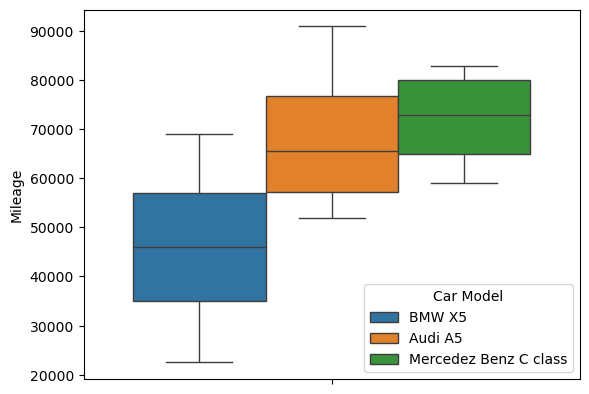

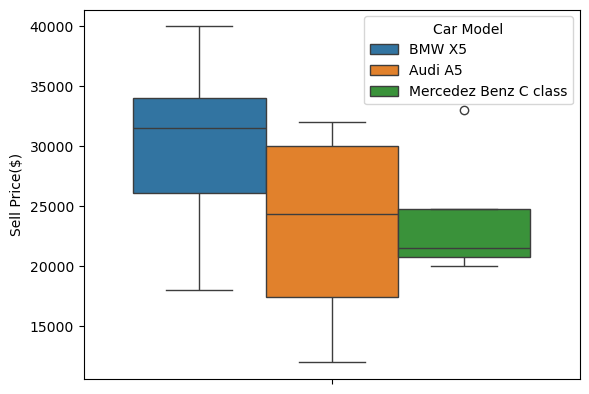

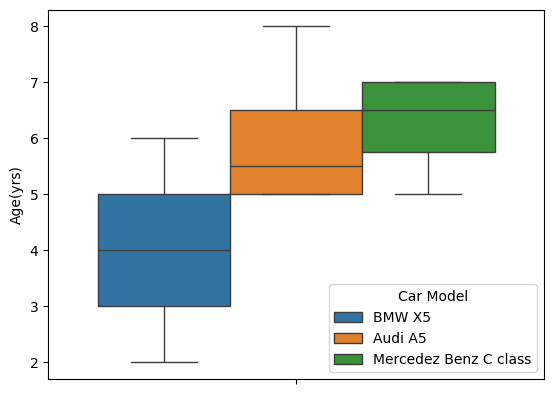

In [79]:
# statistical distribution ckeck
num_cols=df.select_dtypes(["int","float"]).columns
for i in num_cols:
    sns.boxplot(data=df,y=i,hue="Car Model")
    plt.show()
# outlier in  column

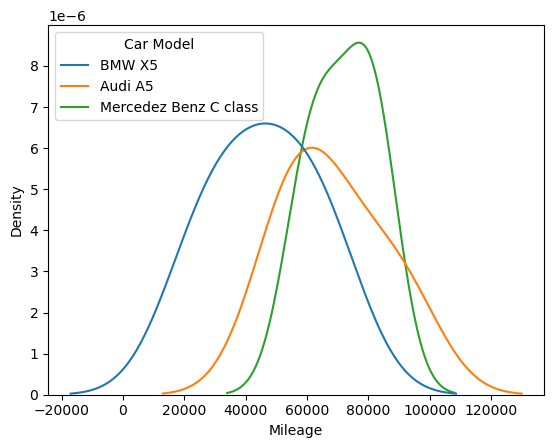

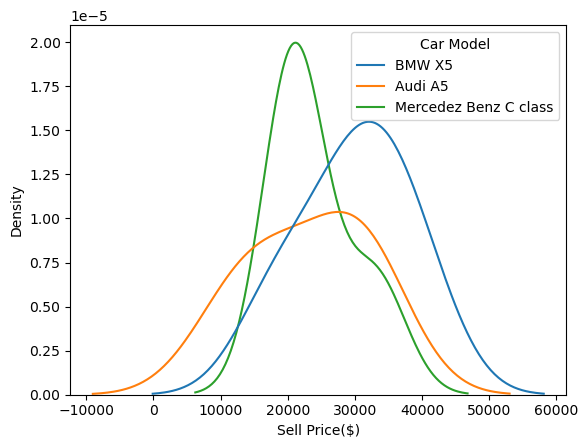

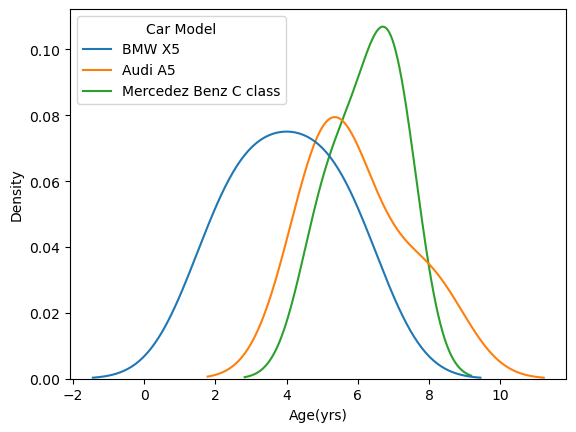

In [80]:
for i in num_cols:
    sns.kdeplot(data=df,x=i,hue="Car Model")
    plt.show()

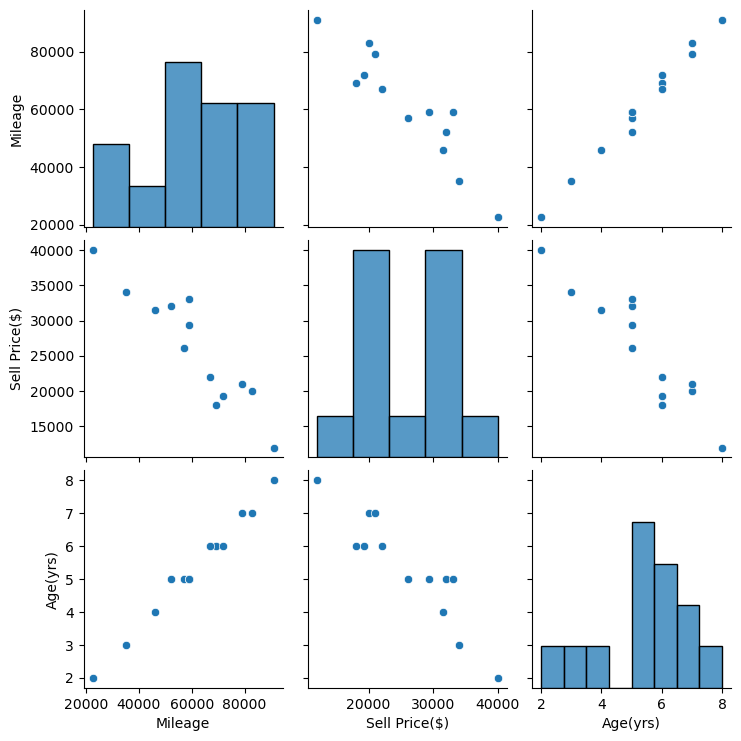

In [81]:
sns.pairplot(df[num_cols])

<Axes: >

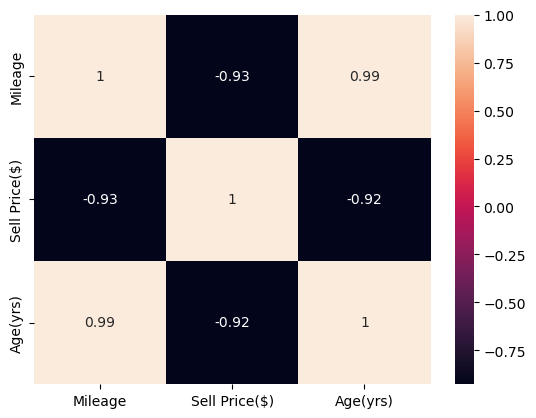

In [82]:
sns.heatmap(df[num_cols].corr(),annot=True)

In [83]:
df["Car Model"]=df["Car Model"].replace(
    {
        "BMW X5":0,
        "Audi A5":1,
        "Mercedez Benz C class":2
    }
)
df["Car Model"].value_counts()

Car Model
0    5
1    4
2    4
Name: count, dtype: int64

In [84]:
features=df.drop("Sell Price($)",axis=1)
target=df["Sell Price($)"]

In [85]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features.iloc[:]=ss.fit_transform(features.iloc[:])
features

,Car Model,Mileage,Age(yrs)
0,-1.114172,0.440264,0.436051
1,-1.114172,-1.404255,-1.453505
2,-1.114172,-0.210743,-0.193801
3,-1.114172,-2.082387,-2.083357
4,-1.114172,-0.807499,-0.823653
5,0.092848,-0.102241,-0.193801
6,0.092848,-0.481995,-0.193801
7,0.092848,0.603016,0.436051
8,0.092848,1.633776,1.695756
9,1.299867,0.331763,0.436051


In [86]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,random_state=0,test_size=0.2)
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(10, 3) (10,)
(3, 3) (3,)


In [87]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

In [88]:
from sklearn.metrics import mean_squared_error,r2_score

def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    # overfitting - underfitting check
    print(f"Train Score : {model.score(xtrain,ytrain)}")
    print(f"Test Score : {model.score(xtest,ytest)}")
    mse=mean_squared_error(ytest, ypred)
    r2=r2_score(ytest,ypred)
    print(f"mse : {mse}")
    print(f"r2 (Model Accuarcy) : {r2}")
    sns.scatterplot(x=ypred,y=(ytest-ypred))
    plt.show()
    sns.kdeplot((ytest-ypred))
    plt.show()
    return model

Train Score : 0.9516232347269323
Test Score : 0.476117876707446
mse : 13475412.393580692
r2 (Model Accuarcy) : 0.476117876707446


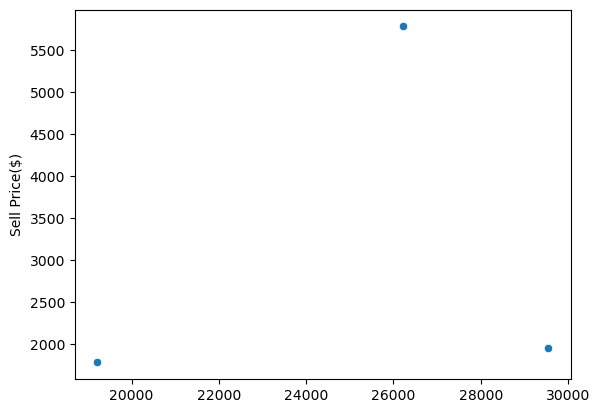

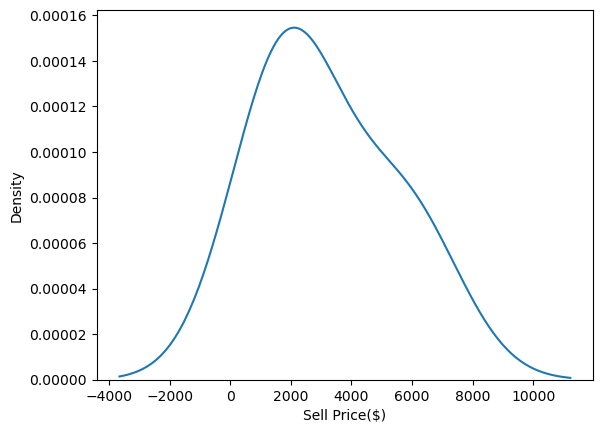

LinearRegression()

In [89]:
lr=mymodel(LinearRegression())
lr
# overfitting

Train Score : 1.0
Test Score : 0.15805615550755925
mse : 21656666.666666668
r2 (Model Accuarcy) : 0.15805615550755925


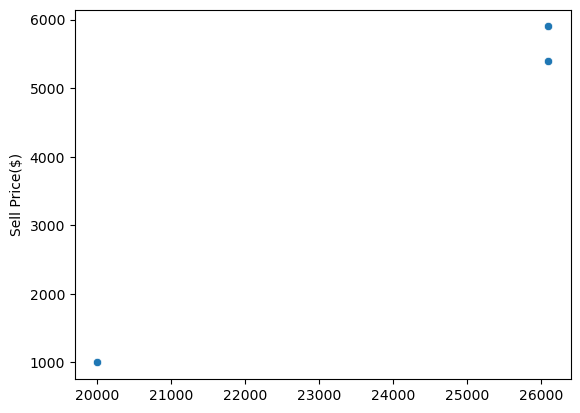

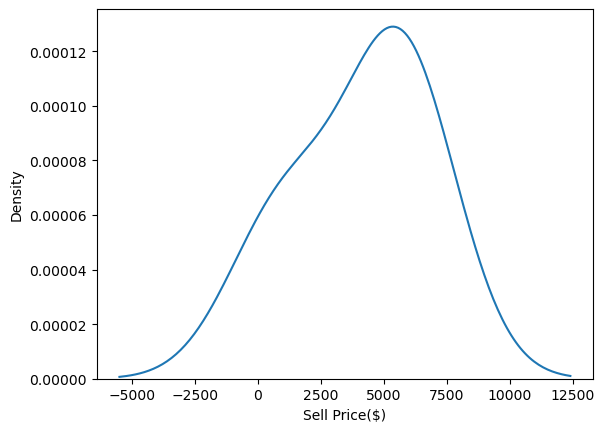

DecisionTreeRegressor()

In [90]:
dt=mymodel(DecisionTreeRegressor())
dt

In [91]:
parameters={
    "max_depth":list(range(2,4)), # 2,3,4
    "min_samples_split":list(range(2,4)), # 2,3,4
    "min_samples_leaf":list(range(3,4)),  #3
    "criterion":["squared_error","absolute_error"]
}
clf=GridSearchCV(DecisionTreeRegressor(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=3; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [2, 3], 'min_samples_leaf': [3],
                         'min_samples_split': [2, 3]},
             verbose=2)

Train Score : 0.7426872283318686
Test Score : 0.9204319654427646
mse : 2046666.6666666667
r2 (Model Accuarcy) : 0.9204319654427646


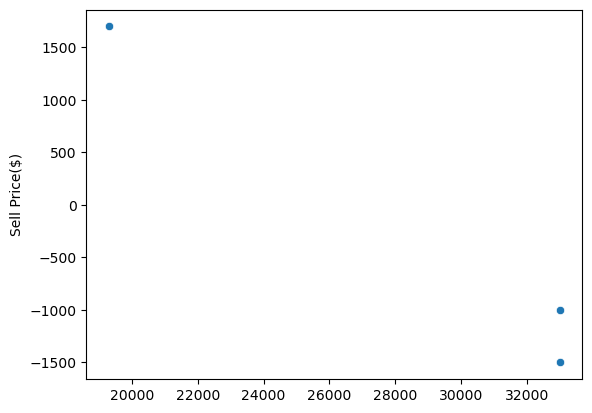

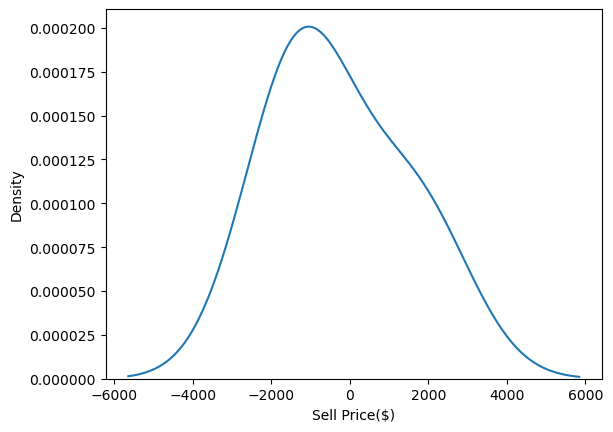

DecisionTreeRegressor(criterion='absolute_error', max_depth=2,
                      min_samples_leaf=3)

In [92]:
dt_ht=mymodel(clf.best_estimator_)
dt_ht

Train Score : 0.9675199000617563
Test Score : 0.5954585917926565
mse : 10405704.0
r2 (Model Accuarcy) : 0.5954585917926565


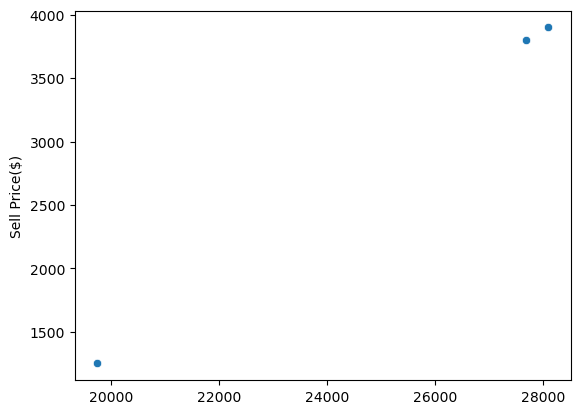

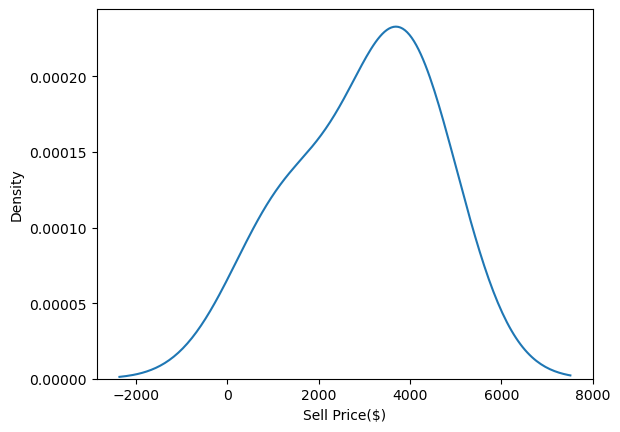

RandomForestRegressor()

In [93]:
rf=mymodel(RandomForestRegressor())
rf

In [95]:
parameters={
    "n_estimators":[70,80,120],
    "max_depth":list(range(2,4)), # 2,3,4
    "min_samples_split":list(range(2,4)), # 2,3,4
    "min_samples_leaf":list(range(3,4)),  #3
    "criterion":["squared_error","absolute_error"]
}
clf=GridSearchCV(RandomForestRegressor(),parameters,verbose=2)
clf.fit(xtrain,ytrain)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=70; total time=   0.1s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=70; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=70; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=70; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=70; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min_samples_split=2, n_estimators=80; total time=   0.0s
[CV] END criterion=squared_error, max_depth=2, min_samples_leaf=3, min

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [2, 3], 'min_samples_leaf': [3],
                         'min_samples_split': [2, 3],
                         'n_estimators': [70, 80, 120]},
             verbose=2)

Train Score : 0.7153994337873286
Test Score : 0.9304982951486498
mse : 1787738.2970097305
r2 (Model Accuarcy) : 0.9304982951486498


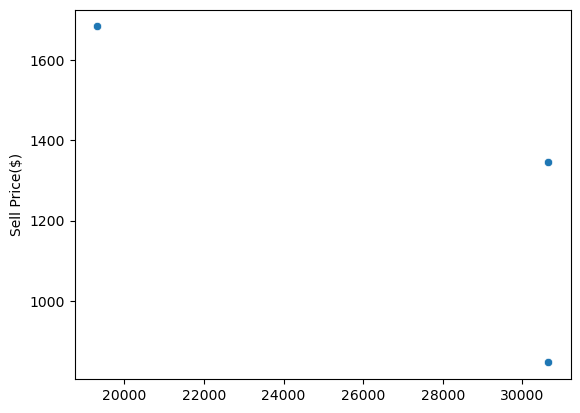

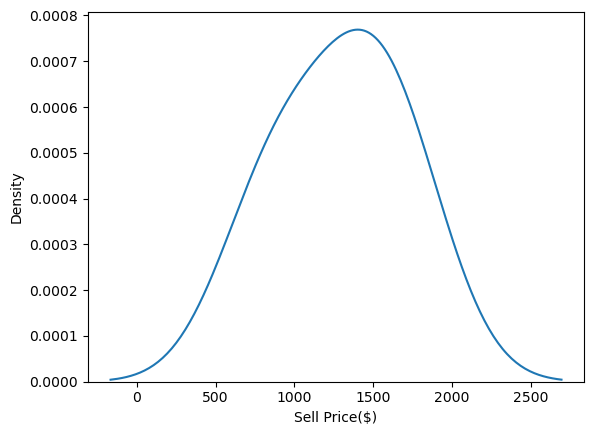

RandomForestRegressor(max_depth=3, min_samples_leaf=3, n_estimators=70)

In [96]:
rf_ht=mymodel(clf.best_estimator_)
rf_ht